In [14]:
%pip install numpy
%pip install pandas
%pip install matplotlib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


(a)

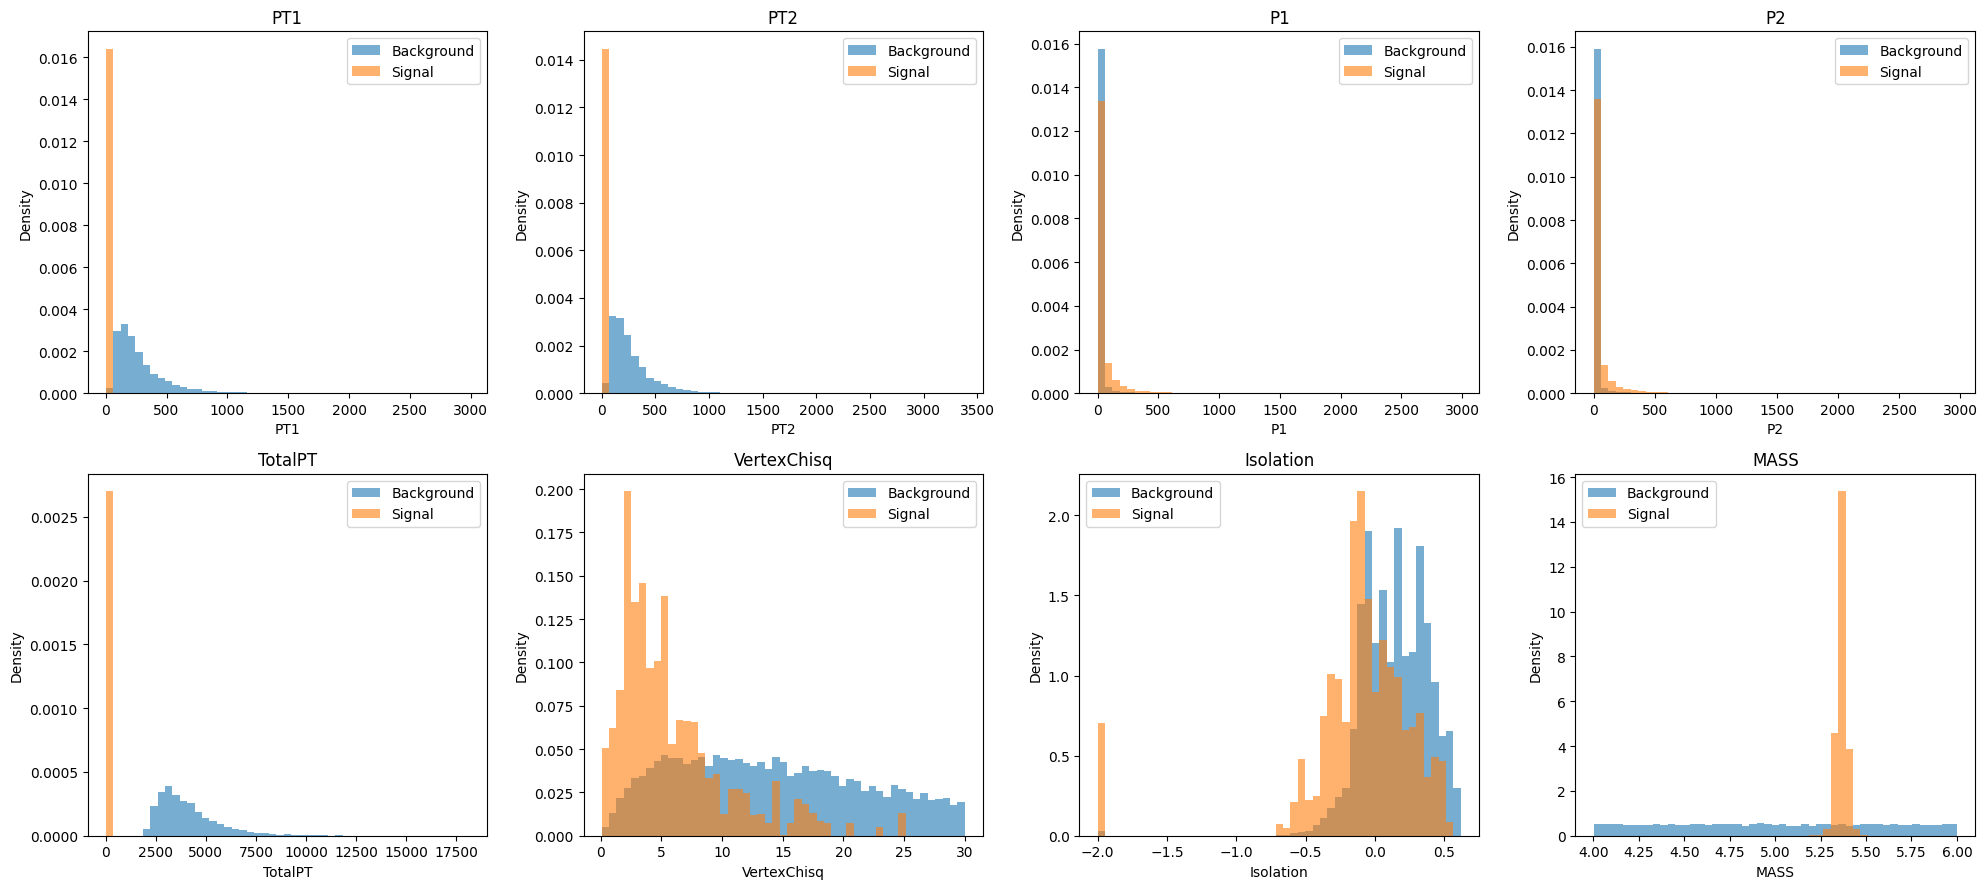

In [ ]:
signal_path = "data/signal_Bs2MuMu.txt"
background_path="data/background_combinatorial.txt"

features = ["PT1", "PT2", "P1", "P2", "TotalPT", "VertexChisq", "Isolation", "MASS"]


#load data 
signal=pd.read_csv(signal_path, sep=r"\s+", header=None, names=features)
background=pd.read_csv(background_path, sep=r"\s+", header=None, names=features)
signal = signal.apply(pd.to_numeric, errors="coerce")
background = background.apply(pd.to_numeric, errors="coerce")
signal = signal.dropna().reset_index(drop=True)
background = background.dropna().reset_index(drop=True)

#store all plots in an output folder
os.makedirs("plots",exist_ok=True)

#now create plot for all features:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feature in enumerate(features): # create one subplot for each feature
    ax = axes[i]
    all_vals = np.concatenate([signal[feature].values, background[feature].values])
    bins = np.linspace(all_vals.min(), all_vals.max(), 50)
    ax.hist(background[feature], bins=bins, alpha=0.6, label="Background", density=True)
    ax.hist(signal[feature], bins=bins, alpha=0.6, label="Signal", density=True)
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig("plots/all_features_overview.png", dpi=300, bbox_inches="tight")
plt.show()


All features can be used except the mass as we will use the mass distribution to fit a signal peak over the background. Using mss in the classifier would therefore bias the distribution 

(b)

In [ ]:
#compute the fisher score as given by the lecture notes 

def fisher_score(sig_col, bkg_col):
    sig_col = np.asarray(sig_col, dtype=float)
    bkg_col = np.asarray(bkg_col, dtype=float)
    all_vals = np.concatenate([sig_col, bkg_col])
    n_sig = len(sig_col)
    n_bkg = len(bkg_col)
    mu_sig = np.mean(sig_col)
    mu_bkg = np.mean(bkg_col)
    mu_all = np.mean(all_vals)
    sigma_all = np.std(all_vals, ddof=0)
    if sigma_all == 0:
        return 0.0

    score=(n_sig*(mu_sig-mu_all)**2+ n_bkg*(mu_bkg-mu_all)**2)/(sigma_all**2)

    return score
scores = []
for feature in features:
    score=fisher_score(signal[feature], background[feature])
    scores.append({"Feature": feature, "FisherScore": score})

fisher_df = pd.DataFrame(scores).sort_values("FisherScore", ascending=False).reset_index(drop=True)

fisher_df["Rank"] = np.arange(1, len(fisher_df) + 1)
fisher_df = fisher_df[["Rank", "Feature", "FisherScore"]]

print("\nFisher score ranking:")
display(fisher_df)

fisher_df.to_csv("fisher_scores.csv", index=False)
print("\nSaved ranking to fisher_scores.csv")


Fisher score ranking:


,Rank,Feature,FisherScore
0,1,TotalPT,15393.795868
1,2,PT2,8852.599773
2,3,PT1,8839.559659
3,4,VertexChisq,5813.935038
4,5,MASS,3377.956929
5,6,Isolation,2316.637714
6,7,P2,663.052874
7,8,P1,657.405893



Saved ranking to fisher_scores.csv


In [19]:
#select top3 features
top3_features = fisher_df.loc[fisher_df["Feature"] != "MASS", "Feature"].head(3).tolist()
print("\nTop 3 non-MASS features used for part (c):", top3_features)


def get_thresholds(sig_vals, bkg_vals, n_points=15):
    all_vals = np.concatenate([sig_vals, bkg_vals])
    qs = np.linspace(2, 98, n_points)  # avoid extreme outliers
    thresholds = np.unique(np.percentile(all_vals, qs))
    return thresholds

def refine_thresholds(sig_vals, bkg_vals, best_t, width_fraction=0.08, n_points=25):
    all_vals = np.concatenate([sig_vals, bkg_vals])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    vrange = vmax - vmin
    low = max(vmin, best_t - width_fraction * vrange)
    high = min(vmax, best_t + width_fraction * vrange)
    thresholds = np.unique(np.linspace(low, high, n_points))
    return thresholds


def compute_metrics(sig_mask, bkg_mask):
    tp = np.sum(sig_mask)
    fn = len(sig_mask) - tp
    fp = np.sum(bkg_mask)
    tn = len(bkg_mask) - fp

    accuracy = (tp + tn) / (len(sig_mask) + len(bkg_mask))
    signal_eff = tp / len(sig_mask)
    background_eff = fp / len(bkg_mask)
    background_rej = 1 - background_eff

    return {
        "TP": int(tp),
        "FN": int(fn),
        "FP": int(fp),
        "TN": int(tn),
        "accuracy": float(accuracy),
        "signal_efficiency": float(signal_eff),
        "background_efficiency": float(background_eff),
        "background_rejection": float(background_rej),
    }

def search_best_rectangular_cut(signal_df, background_df, chosen_features, threshold_dict):
    pre_sig = {}
    pre_bkg = {}

    for feat in chosen_features:
        x_sig = signal_df[feat].to_numpy()
        x_bkg = background_df[feat].to_numpy()
        ts = threshold_dict[feat]

        pre_sig[feat] = {
            ">": [x_sig > t for t in ts],
            "<": [x_sig < t for t in ts],
        }
        pre_bkg[feat] = {
            ">": [x_bkg > t for t in ts],
            "<": [x_bkg < t for t in ts],
        }

    f1, f2, f3 = chosen_features
    t1s, t2s, t3s = threshold_dict[f1], threshold_dict[f2], threshold_dict[f3]

    best = None

    for d1, d2, d3 in product([">", "<"], repeat=3):
        for i in range(len(t1s)):
            s1 = pre_sig[f1][d1][i]
            b1 = pre_bkg[f1][d1][i]

            for j in range(len(t2s)):
                s12 = s1 & pre_sig[f2][d2][j]
                b12 = b1 & pre_bkg[f2][d2][j]

                for k in range(len(t3s)):
                    s123 = s12 & pre_sig[f3][d3][k]
                    b123 = b12 & pre_bkg[f3][d3][k]

                    metrics = compute_metrics(s123, b123)

                    if best is None or metrics["accuracy"] > best["accuracy"]:
                        best = {
                            "features": chosen_features,
                            "cuts": {
                                f1: (d1, float(t1s[i])),
                                f2: (d2, float(t2s[j])),
                                f3: (d3, float(t3s[k])),
                            },
                            **metrics
                        }

    return best

coarse_thresholds = {
    feat: get_thresholds(signal[feat].to_numpy(), background[feat].to_numpy(), n_points=15)
    for feat in top3_features
}

best_coarse = search_best_rectangular_cut(signal, background, top3_features, coarse_thresholds)

print("\nBest coarse solution:")
print(best_coarse)

refined_thresholds = {}
for feat in top3_features:
    _, best_t = best_coarse["cuts"][feat]
    refined_thresholds[feat] = refine_thresholds(
        signal[feat].to_numpy(),
        background[feat].to_numpy(),
        best_t=best_t,
        width_fraction=0.08,
        n_points=25
    )

best_final = search_best_rectangular_cut(signal, background, top3_features, refined_thresholds)

print("\nBest refined rectangular selection:")
print(best_final)

summary_df = pd.DataFrame({
    "Feature": top3_features,
    "Direction": [best_final["cuts"][f][0] for f in top3_features],
    "Threshold": [best_final["cuts"][f][1] for f in top3_features],
})

print("\nOptimal rectangular cut:")
display(summary_df)
print(f"Accuracy              = {best_final['accuracy']:.4f}")
print(f"Signal efficiency     = {best_final['signal_efficiency']:.4f}")
print(f"Background efficiency = {best_final['background_efficiency']:.4f}")
print(f"Background rejection  = {best_final['background_rejection']:.4f}")

print("\nConfusion counts:")
print(f"TP = {best_final['TP']}, FN = {best_final['FN']}, FP = {best_final['FP']}, TN = {best_final['TN']}")


def apply_rectangular_selection(df, cut_dict):
    mask = np.ones(len(df), dtype=bool)
    for feat, (direction, threshold) in cut_dict.items():
        if direction == ">":
            mask &= (df[feat].to_numpy() > threshold)
        else:
            mask &= (df[feat].to_numpy() < threshold)
    return mask

signal_selected_mask = apply_rectangular_selection(signal, best_final["cuts"])
background_selected_mask = apply_rectangular_selection(background, best_final["cuts"])

print("\nEvents passing the rectangular cut:")
print("Signal passing:", int(np.sum(signal_selected_mask)))
print("Background passing:", int(np.sum(background_selected_mask)))


Top 3 non-MASS features used for part (c): ['TotalPT', 'PT2', 'PT1']

Best coarse solution:
{'features': ['TotalPT', 'PT2', 'PT1'], 'cuts': {'TotalPT': ('<', 1035.5343488733201), 'PT2': ('<', 106.04212192948096), 'PT1': ('<', 104.7132329198266)}, 'TP': 10000, 'FN': 0, 'FP': 0, 'TN': 10000, 'accuracy': 1.0, 'signal_efficiency': 1.0, 'background_efficiency': 0.0, 'background_rejection': 1.0}

Best refined rectangular selection:
{'features': ['TotalPT', 'PT2', 'PT1'], 'cuts': {'TotalPT': ('<', 103.58513320604395), 'PT2': ('<', 47.12939626496172), 'PT1': ('<', 71.56237411474577)}, 'TP': 10000, 'FN': 0, 'FP': 0, 'TN': 10000, 'accuracy': 1.0, 'signal_efficiency': 1.0, 'background_efficiency': 0.0, 'background_rejection': 1.0}

Optimal rectangular cut:


,Feature,Direction,Threshold
0,TotalPT,<,103.585133
1,PT2,<,47.129396
2,PT1,<,71.562374


Accuracy              = 1.0000
Signal efficiency     = 1.0000
Background efficiency = 0.0000
Background rejection  = 1.0000

Confusion counts:
TP = 10000, FN = 0, FP = 0, TN = 10000

Events passing the rectangular cut:
Signal passing: 10000
Background passing: 0


In [16]:
for f in top3_features:
    print(f"\n{f}")
    print(" signal   min/max:", signal[f].min(), signal[f].max())
    print(" background min/max:", background[f].min(), background[f].max())


TotalPT
 signal   min/max: 0.0101002787602682 60.85427035338376
 background min/max: 2010.2144273932568 18128.466871031866

PT2
 signal   min/max: 0.0218228325558168 45.05557593693479
 background min/max: 30.08063097696527 3385.525427361581

PT1
 signal   min/max: 0.0119354667482033 57.50077667510212
 background min/max: 35.23460080649885 2984.2720361831225


In [17]:
cuts = best_final["cuts"]

for f, (direction, thr) in cuts.items():
    if direction == "<":
        sig_pass = (signal[f] < thr).mean()
        bkg_pass = (background[f] < thr).mean()
    else:
        sig_pass = (signal[f] > thr).mean()
        bkg_pass = (background[f] > thr).mean()
    print(f"{f}: {direction} {thr:.6f} | signal pass = {sig_pass:.4f}, background pass = {bkg_pass:.4f}")

TotalPT: < 103.585133 | signal pass = 1.0000, background pass = 0.0000
PT2: < 47.129396 | signal pass = 1.0000, background pass = 0.0051
PT1: < 71.562374 | signal pass = 1.0000, background pass = 0.0340


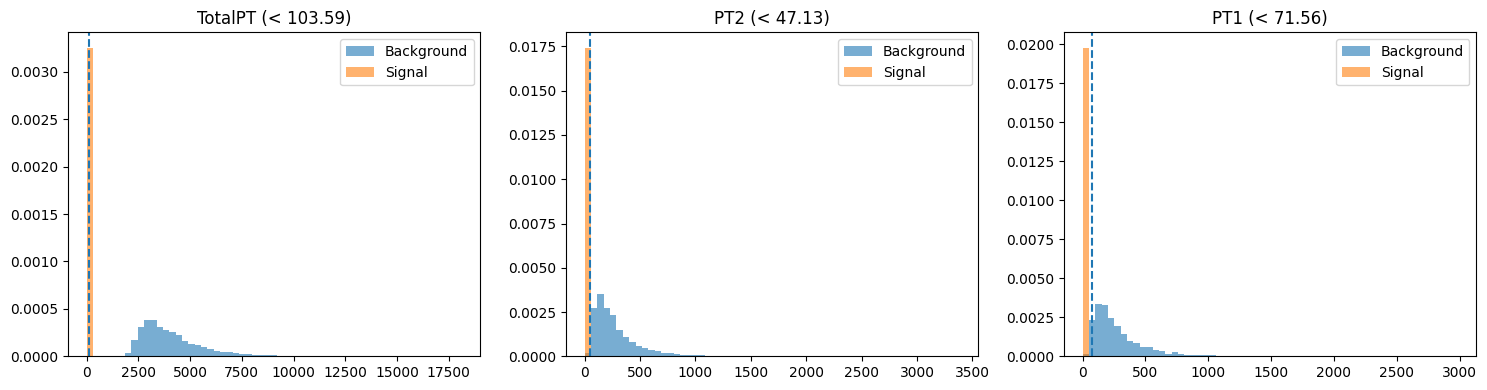

In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, f in zip(axes, top3_features):
    all_vals = np.concatenate([signal[f].to_numpy(), background[f].to_numpy()])
    bins = np.linspace(all_vals.min(), all_vals.max(), 60)

    ax.hist(background[f], bins=bins, alpha=0.6, density=True, label="Background")
    ax.hist(signal[f], bins=bins, alpha=0.6, density=True, label="Signal")

    direction, thr = best_final["cuts"][f]
    ax.axvline(thr, linestyle="--")
    ax.set_title(f"{f} ({direction} {thr:.2f})")
    ax.legend()

plt.tight_layout()
plt.show()